In [2]:
import math

import matplotlib.pyplot as plt
import os

from tensorflow.keras.datasets import mnist 
from tensorflow.keras.layers import * 
from tensorflow.keras.models import load_model, save_model
import tensorflow as tf
from tensorflow import keras

import numpy as np 
from nnom import * 

In [3]:
model_name = 'mnist_simple_trained_model.h5'

def image_to_cfile(data, label, num_of_image, file='image.h'): 
    with open(file, 'w') as f: 
        for i in range(num_of_image): 
            selected = np.random.randint(0, 1000)
            f.write('#define IMG%d{' %(i))
            np.round(data[selected]).flatten().tofile(f, sep=", ", format="%d")
            f.write('} \n')
            f.write('#define IMG%d_LABEL'% (i))
            f.write(' %d\n \n' % label[selected])
        f.write('#define TOTAL_IMAGE %d \n \n' %(num_of_image))

        f.write('static const int8_t img[%d][%d] = {' %(num_of_image, data[0].flatten().shape[0]))
        f.write('IMG0')
        for i in range(num_of_image - 1):
            f.write(', IMG%d' %(i+1))
        f.write('};\n\n')

        f.write('static const int8_t label[%d] = {' %(num_of_image))
        f.write('IMG0_LABEL')
        for i in range(num_of_image - 1):
            f.write(', IMG%d_LABEL' %(i+1))
        f.write('};\n\n')

In [4]:
def train(x_train, y_train, x_test, y_test, batch_size=64, epochs=100):
    inputs = Input(shape=x_train.shape[1:])
    x = Conv2D(12, kernel_size=(3, 3), strides=(1, 1), padding='same')(inputs)
    x = ReLU()(x)
    x = MaxPool2D((2,2),strides=(2,2), padding="same")(x)

    x = Conv2D(24 ,kernel_size=(3,3), strides=(1,1), padding="same")(x)
    x = ReLU()(x)
    x = MaxPool2D((2,2),strides=(2,2), padding="same")(x)

    x = Conv2D(48, kernel_size=(3,3), strides=(1,1), padding="same")(x)
    x = ReLU()(x)
    x = Dropout(0.2)(x)
    x = MaxPool2D((2,2),strides=(2,2), padding="same")(x)
    
    x = Flatten()(x)
    x = Dense(96)(x)
    x = Dropout(0.2)(x)

    x = ReLU()(x)
    x = Dense(10)(x)
    predictions = Softmax()(x)

    model = Model(inputs=inputs, outputs=predictions)

    model.compile(loss='categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])
    model.summary()

    history =  model.fit(x_train, y_train,
              batch_size=batch_size,
              epochs=epochs,
              verbose=2,
              validation_data=(x_test, y_test),
              shuffle=True)
    
    # free the session to avoid nesting naming whiel we load the best model after 
    save_model(model, model_name)
    del model
    tf.keras.backend.clear_session()
    return history

60000 train samples
10000 test samples
x_train shape: (60000, 28, 28, 1)
data range 0.0 1.0
Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 28, 28, 1)]       0         
                                                                 
 conv2d_3 (Conv2D)           (None, 28, 28, 12)        120       
                                                                 
 re_lu_4 (ReLU)              (None, 28, 28, 12)        0         
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 14, 14, 12)        0         
 g2D)                                                            
                                                                 
 conv2d_4 (Conv2D)           (None, 14, 14, 24)        2616      
                                                                 
 re_lu_5 (ReLU)              (Non

C:\Users\WonResearchGroup\AppData\Local\Temp\ipykernel_37792\3614422702.py:39: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  save_model(model, model_name)


313/313 - 1s - loss: 0.0378 - accuracy: 0.9880 - 967ms/epoch - 3ms/step
Test loss: 0.037805549800395966
Top 1: 0.9879999756813049
313/313 [==============================] - 1s 3ms/step
[[ 971    1    1    0    0    0    3    1    3    0]
 [   0 1131    1    1    0    0    1    0    1    0]
 [   0    0 1022    2    0    0    0    4    4    0]
 [   0    0    0 1002    0    2    0    3    3    0]
 [   0    1    0    0  977    0    2    0    1    1]
 [   1    0    0    4    0  883    1    0    2    1]
 [   4    3    0    0    7    2  937    0    5    0]
 [   0    2    3    3    2    0    0 1016    2    0]
 [   0    0    2    3    1    2    0    0  964    2]
 [   1    5    0    3   10    0    0    7    6  977]]
input_2 Quantized method: max-min  Values max: 1.0 min: 0.0 dec bit 7
2188/2188 [==============================] - 5s 2ms/step
conv2d_3 Quantized method: max-min  Values max: 1.4864471 min: -1.0160161 dec bit 6
re_lu_4 Quantized method: max-min  Values max: 1.4864471 min: -1.0160161 

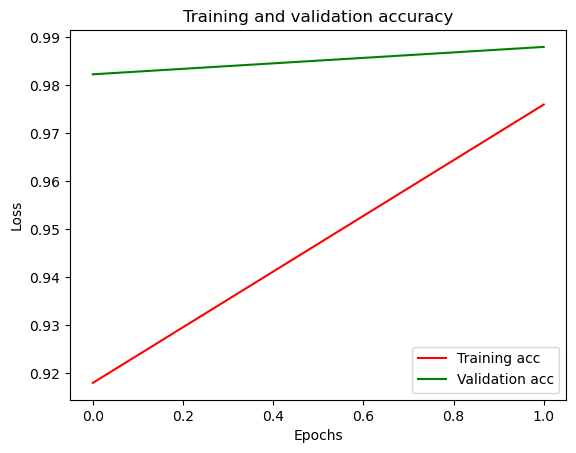

In [6]:
# set hyperparameters and perform training 
epochs = 2 
num_classes = 10 

(x_train, y_train_num), (x_test, y_test_num)= mnist.load_data()

print(x_train.shape[0], 'train samples')
print(x_test.shape[0], 'test samples')

y_train = utils.to_categorical(y_train_num, num_classes)
y_test = utils.to_categorical(y_test_num, num_classes)

x_train = x_train.reshape(x_train.shape[0], x_train.shape[1], x_train.shape[2], 1)
x_test = x_test.reshape(x_test.shape[0], x_test.shape[1], x_test.shape[2], 1)
print('x_train shape:', x_train.shape)

# normalize the range to 0~255 -> 0~1 
x_test = x_test/255
x_train = x_train/255
print("data range", x_test.min(), x_test.max()) 

# select a few image and write them to image.h 
image_to_cfile(x_test*127, y_test_num, 10, file='image.h')  

# train model, save the best accuracy model 
history = train(x_train, y_train, x_test, y_test, batch_size=64, epochs=epochs)

model = load_model(model_name)

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

evaluate_model(model, x_test, y_test)
generate_model(model, np.vstack((x_train, x_test)), name="weights.h")

plt.plot(range(0, epochs), acc, color='red', label='Training acc')
plt.plot(range(0, epochs), val_acc, color='green', label="Validation acc")
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()